In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
import matplotlib.pyplot as plt
import time

# ================== 1. 终极参数 (3x+1 动力学沙盒) ==================
MU = 1.7548776662466927  # 周期-3窗口的精确解析根
N_BINS = 10000           # 高分辨率相空间切分
EPS = 0.0005             # 高斯扩散核的宽度
DX = 2.0 / N_BINS

X_STAR = (-1.0 + np.sqrt(1.0 + 4.0 * MU)) / (2.0 * MU)
print(f"定制马尔可夫划分阈值 x* = {X_STAR:.6f}")

# ================== 2. 构建静态转移算子 (PF 矩阵) ==================
def build_static_transfer_matrix(n_bins, mu, eps, dx):
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1
    
    xs = np.linspace(-1.0 + dx*0.5, 1.0 - dx*0.5, n_bins)
    x_next = 1.0 - mu * xs * xs
    
    for i in range(n_bins):
        xn = x_next[i]
        j_center = int((xn + 1.0) / dx)
        j_start = max(0, j_center - radius)
        j_end = min(n_bins - 1, j_center + radius)
        
        cj = xs[j_start:j_end+1]
        probs = np.exp(-(cj - xn)**2 * inv_2eps2)
        w_sum = np.sum(probs)
        
        if w_sum > 1e-18:
            transitions[i, j_start:j_end+1] = probs / w_sum
        else:
            jc = min(max(0, j_center), n_bins - 1)
            transitions[i, jc] = 1.0
            
    return transitions

print("构建连续空间的高精度 PF 转移矩阵...")
start_t = time.time()
trans_matrix = build_static_transfer_matrix(N_BINS, MU, EPS, DX)
P_sparse = sp.csr_matrix(trans_matrix)
print(f"构建完成！耗时: {time.time() - start_t:.2f} 秒\n")

# ================== 3. 提取算子本征谱 ==================
# 注意！原矩阵是行随机矩阵，求不变量测度是对转置矩阵求右特征向量
vals, vecs = eigs(P_sparse.T, k=25, which='LM') 

# 按模长降序排列
idx = np.argsort(np.abs(vals))[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

print("Top Eigenvalues (magnitudes):")
for i in range(5):
    print(f"λ_{i+1}: |λ|={np.abs(vals[i]):.6f} (val: {vals[i].real:.4f} + {vals[i].imag:.4f}j)")

lambda_4 = vals[3] # 第一个严格小于1的本征值 (代表暂态混沌的衰减)
kappa = -np.log(np.abs(lambda_4))
print(f"\n=> 理论逃逸率 (Transient Decay) κ = -ln|λ_4| = {kappa:.6f}\n")

# ================== 4. 2:1 不变测度验证 ==================
rho = np.abs(vecs[:, 0])
rho /= np.sum(rho * DX) # 概率密度归一化

xs = np.linspace(-1 + DX/2, 1 - DX/2, N_BINS)
state_0_mask = xs < X_STAR
state_1_mask = xs >= X_STAR

measure_0 = np.sum(rho[state_0_mask] * DX)
measure_1 = np.sum(rho[state_1_mask] * DX)

print(f"状态 0 (偶数/收缩) 积分测度: {measure_0:.6f} (理论: 2/3)")
print(f"状态 1 (奇数/膨胀) 积分测度: {measure_1:.6f} (理论: 1/3)")

定制马尔可夫划分阈值 x* = 0.521938
构建连续空间的高精度 PF 转移矩阵...
构建完成！耗时: 0.64 秒

Top Eigenvalues (magnitudes):
λ_1: |λ|=1.000000 (val: 1.0000 + 0.0000j)
λ_2: |λ|=1.000000 (val: -0.5000 + 0.8660j)
λ_3: |λ|=1.000000 (val: -0.5000 + -0.8660j)
λ_4: |λ|=0.967924 (val: 0.9679 + 0.0000j)
λ_5: |λ|=0.780794 (val: -0.3953 + -0.6734j)

=> 理论逃逸率 (Transient Decay) κ = -ln|λ_4| = 0.032602

状态 0 (偶数/收缩) 积分测度: 0.666667 (理论: 2/3)
状态 1 (奇数/膨胀) 积分测度: 0.333333 (理论: 1/3)


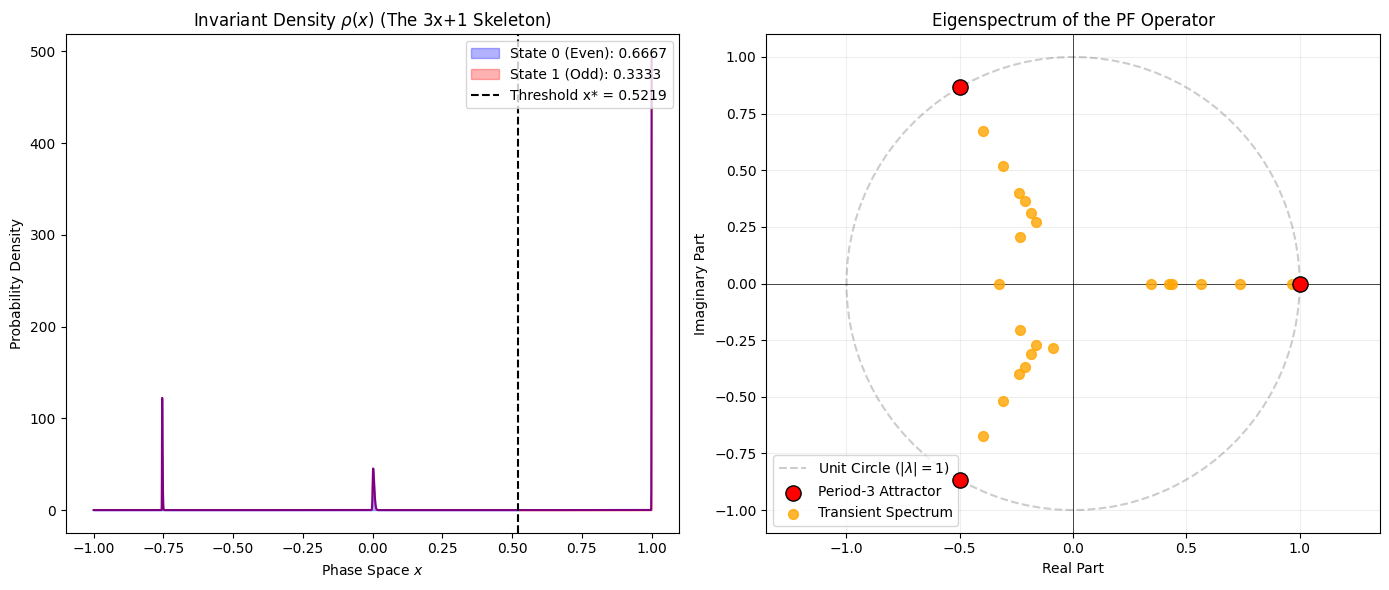

🎉 绝美神图已生成：collatz_spectrum.png


In [2]:
# ================== 5. 顶级期刊质感绘图 ==================
# （接在你刚才代码的后面）

# 图1：2:1 测度与定海神针
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(xs, rho, color='purple', linewidth=1.5)
plt.fill_between(xs[state_0_mask], rho[state_0_mask], color='blue', alpha=0.3, label=f'State 0 (Even): {measure_0:.4f}')
plt.fill_between(xs[state_1_mask], rho[state_1_mask], color='red', alpha=0.3, label=f'State 1 (Odd): {measure_1:.4f}')
plt.axvline(x=X_STAR, color='black', linestyle='--', label=f'Threshold x* = {X_STAR:.4f}')
plt.title('Invariant Density $\\rho(x)$ (The 3x+1 Skeleton)')
plt.xlabel('Phase Space $x$')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')

# 图2：复平面上的本征谱（心电图）
plt.subplot(1, 2, 2)
angles = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(angles), np.sin(angles), 'k--', alpha=0.2, label='Unit Circle ($|\\lambda|=1$)')

# 画出周期3的三次单位根（绝对稳态）
plt.scatter(vals[:3].real, vals[:3].imag, color='red', s=120, edgecolor='black', zorder=6, label='Period-3 Attractor')
# 画出决定衰减的长尾本征值（暂态混沌）
plt.scatter(vals[3:].real, vals[3:].imag, color='orange', s=50, alpha=0.8, zorder=5, label='Transient Spectrum')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Eigenspectrum of the PF Operator')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)
plt.axis('equal')

plt.tight_layout()
plt.savefig('collatz_spectrum.png', dpi=300)
plt.show()
print("🎉 绝美神图已生成：collatz_spectrum.png")